# Laboration 2: Modelling Wine Quality

**Name(s):**
**Date:**

Follow `instructions.md` for the full task description, timing, and the
Checkpoint questions. This notebook is your **working notebook** — light
comments are enough here; your answers to the Checkpoints go on a
**separate answer sheet**, not in this file.

Sections below are labelled to match the instructions exactly
(Step 1 / Step 2 / Step 3 / Step 4) so you can move through the 4-hour
session without hunting for where each part goes.

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict
from sklearn.metrics import (mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, classification_report)

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42  # keep this fixed so your results are reproducible

---
## Step 1 — Data Curation (0:00–0:30)

- [ ] Load the data, check shape / columns / dtypes
- [ ] Check for missing values
- [ ] Check for duplicate rows — look closely before deciding what to do (→ **Checkpoint 1a**)
- [ ] Look at the distribution of `quality` (→ **Checkpoint 1b**)
- [ ] Standardise the 11 predictor variables, ready for Step 2

In [93]:
# Load the data (red wine is the primary dataset for Steps 1-3)

# Download the files from github if you are working on uppmax/colab
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv

df = pd.read_csv('winequality-red.csv', sep=';')
df.head()

--2026-09-25 12:55:00--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84199 (82K) [text/plain]
Saving to: ‘winequality-red.csv.4’

winequality-red.csv 100%[===================>]  82.23K  --.-KB/s    in 0.01s   

2026-09-25 12:55:00 (5.53 MB/s) - ‘winequality-red.csv.4’ saved [84199/84199]

--2026-09-25 12:55:00--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [94]:
# TODO: check the shape, column names, and dtypes
print("shape:" , df.shape)
df.info()

shape: (1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [95]:
# TODO: check for missing values

print(df.isna().sum()) #check how many NaNs in each column

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [96]:
# TODO: check for duplicate rows (df.duplicated())
# How many are there? What will you do about them, and why?
# -- write your reasoning on the answer sheet (Checkpoint 1a), not here
print("Number of duplicate rows:",df.duplicated().sum()) #check if there are duplicates

df_bad = df
df = df.drop_duplicates()



Number of duplicate rows: 240


<Axes: >

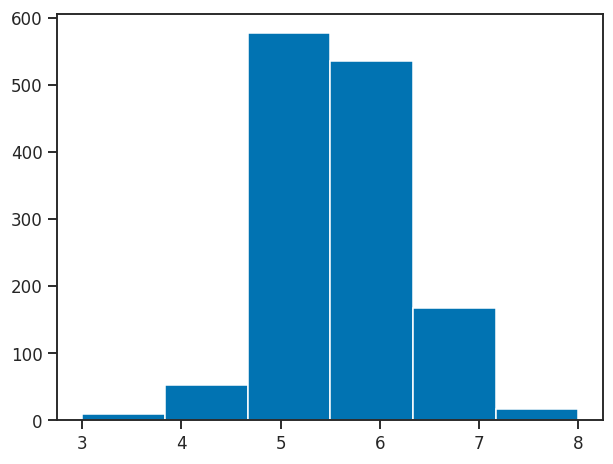

In [97]:
# TODO: look at the distribution of `quality`
# (value_counts() and/or a histogram are both fine)
df['quality'].hist(bins = 6, grid=False)


In [98]:
# TODO: separate predictors (X, the 11 physicochemical columns) from the
# response (y = quality), then standardise X ready for PCA.
# Hint: StandardScaler().fit_transform(X) -- do NOT standardise quality itself.

X = df.drop('quality', axis=1)
y = df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

---
## Step 2 — PCA (0:30–1:30)

Fit PCA on the **standardised predictors only** — `quality` is the response
you are trying to predict, not a predictor, so it must not go into the PCA.

- [ ] Fit PCA, produce a scree plot (individual + cumulative variance)
- [ ] Decide how many components to keep, and by which criterion (→ **Checkpoint 2a**)
- [ ] Score plot (PC1 vs PC2), coloured by `quality` (→ **Checkpoint 2b**)
- [ ] Loading plot for the same two components (→ **Checkpoint 2c**)

In [99]:
# TODO: fit PCA on the standardised predictor matrix
pca = PCA()
scores = pca.fit_transform(X_scaled)


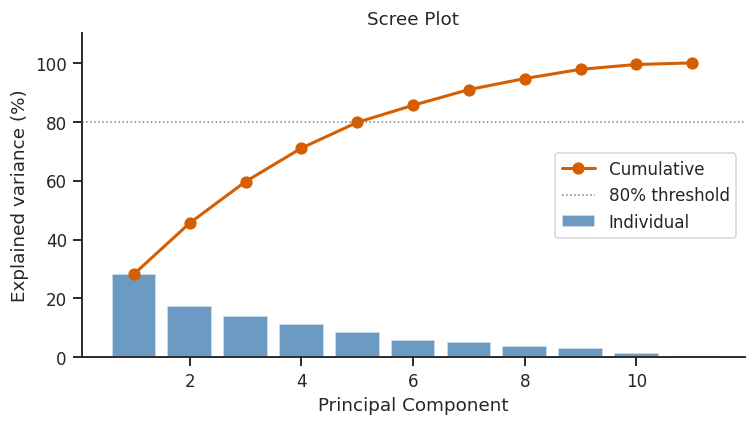

In [100]:
# TODO: scree plot -- individual explained variance (bars) and
# cumulative explained variance (line), same style as the course notebooks
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.8, label='Individual')
ax.plot(range(1, len(explained)+1), cumulative*100, 'ro-', lw=2, ms=7, label='Cumulative')
ax.axhline(80, color='gray', ls=':', lw=1, label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('Scree Plot')
ax.legend()
ax.set_ylim(0, 110)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

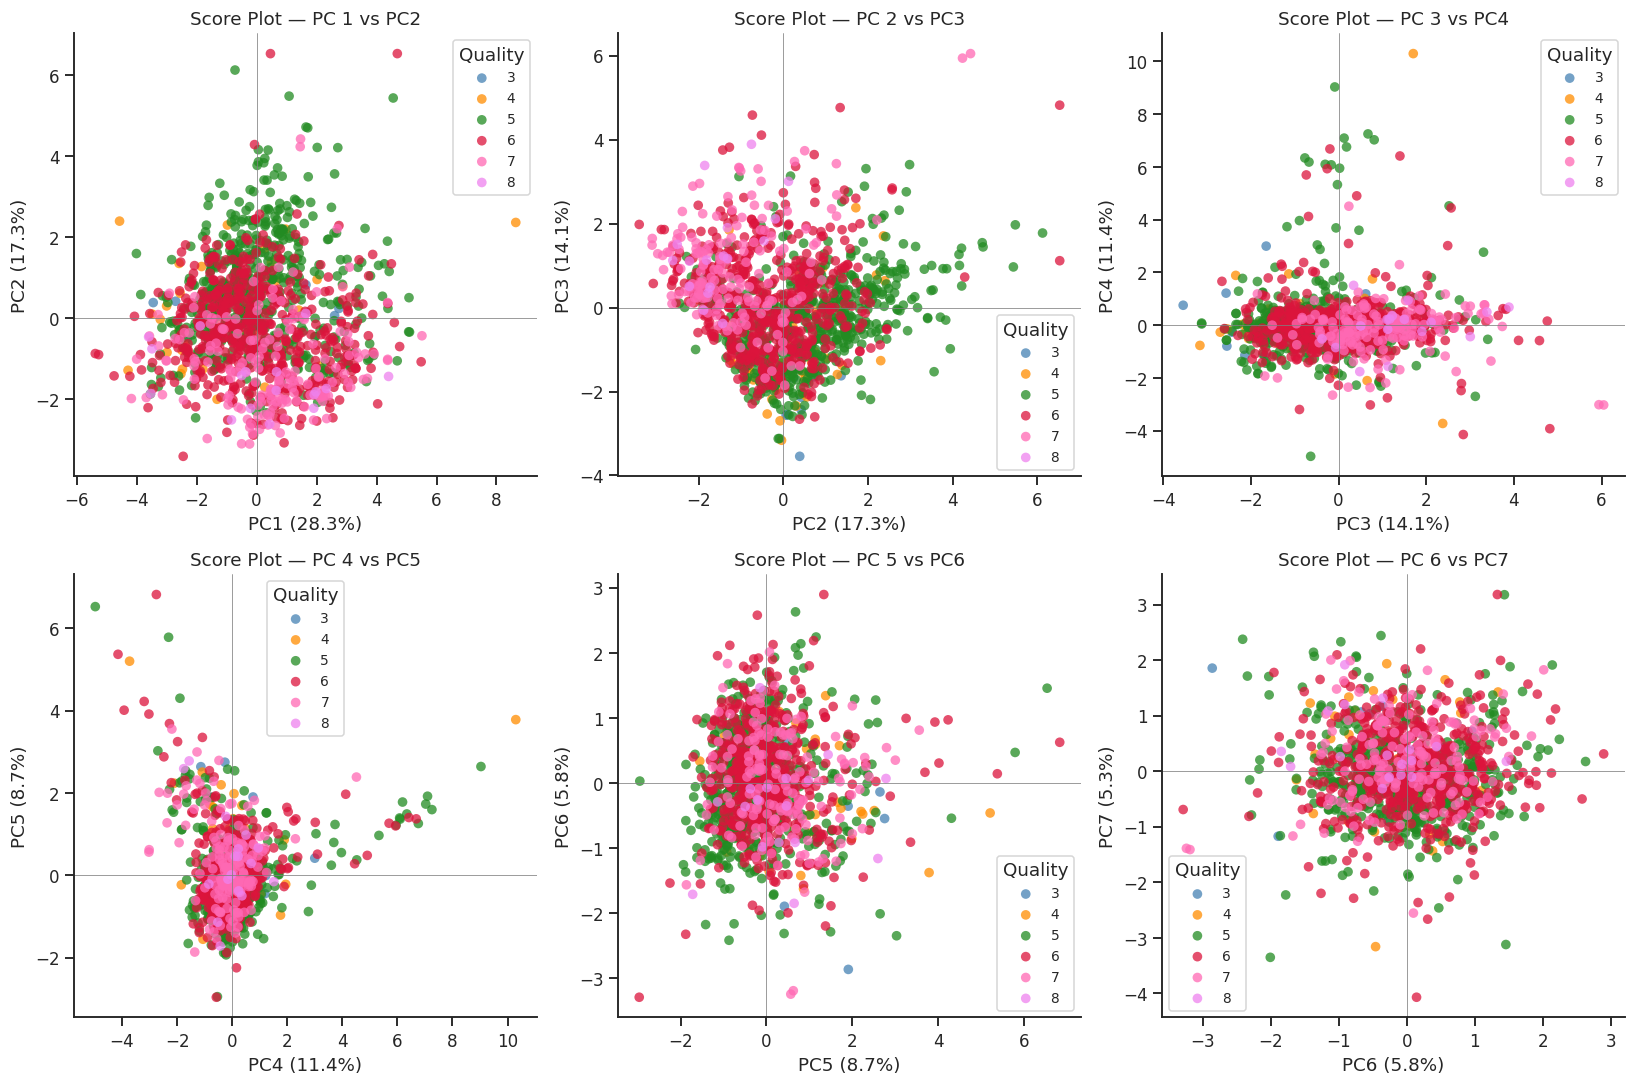

In [101]:
# TODO: score plot -- PC1 vs PC2, colour the points by `quality`
# (a continuous colourmap, e.g. cmap='viridis', works well for an ordinal 0-10 score)

qualities = df['quality'].values
quality_list = [3,4,5,6,7,8]
colors_map = dict(zip(quality_list, ['steelblue','darkorange','forestgreen','crimson','hotpink', 'violet']))
point_colors = [colors_map[q] for q in qualities]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i in range(3):
  ax = axes[0,i]
  for quality, color in colors_map.items():
      mask = qualities == quality
      ax.scatter(scores[mask, i], scores[mask, i+1], c=color,
                 label=quality, s=40, alpha=0.75, edgecolors='none')
  ax.set_xlabel(f'PC{i+1} ({explained[i]*100:.1f}%)')
  ax.set_ylabel(f'PC{i+2} ({explained[i+1]*100:.1f}%)')
  ax.set_title(f'Score Plot — PC {i+1} vs PC{i+2}')
  ax.legend(title='Quality', fontsize=9)
  ax.axhline(0, color='gray', lw=0.5)
  ax.axvline(0, color='gray', lw=0.5)
  sns.despine(ax=ax)
  i=+1
for i in range(3,6):
  ax = axes[1,i-3]
  for quality, color in colors_map.items():
      mask = qualities == quality
      ax.scatter(scores[mask, i], scores[mask, i+1], c=color,
                 label=quality, s=40, alpha=0.75, edgecolors='none')
  ax.set_xlabel(f'PC{i+1} ({explained[i]*100:.1f}%)')
  ax.set_ylabel(f'PC{i+2} ({explained[i+1]*100:.1f}%)')
  ax.set_title(f'Score Plot — PC {i+1} vs PC{i+2}')
  ax.legend(title='Quality', fontsize=9)
  ax.axhline(0, color='gray', lw=0.5)
  ax.axvline(0, color='gray', lw=0.5)
  sns.despine(ax=ax)
  i=+1
fig.tight_layout()
plt.show()




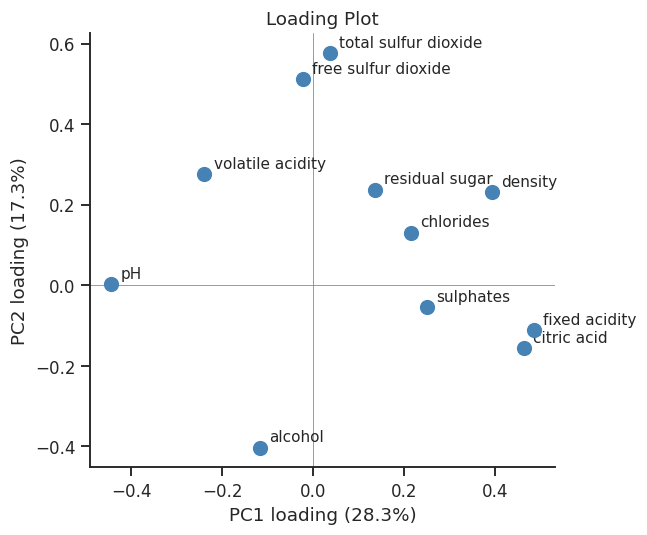

In [102]:
# TODO: loading plot for PC1 vs PC2 -- which variables have the largest
# loadings, and in which direction?

parameters= df.columns[:-1]
loadings = pca.components_.T   # shape (n_variables, n_components)

# Loading plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(loadings[:, 0], loadings[:, 1], color='steelblue', s=80, zorder=5)
for i, elem in enumerate(parameters):
    ax.annotate(elem, (loadings[i, 0], loadings[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(f'PC1 loading ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 loading ({explained[1]*100:.1f}%)')
ax.set_title('Loading Plot')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


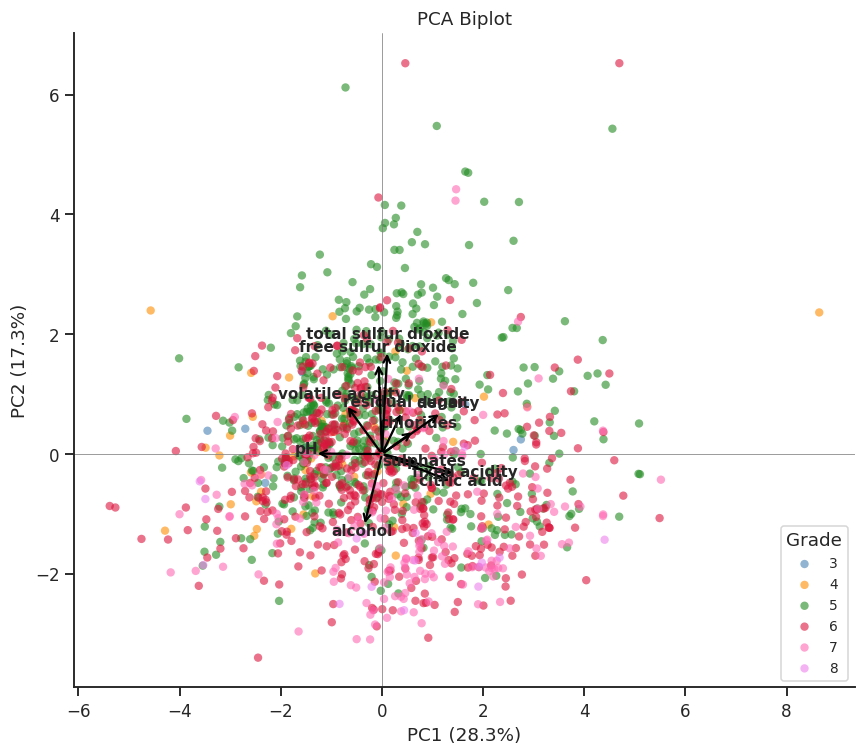

In [103]:

scale = 3.0   # scale factor to make arrows visible

fig, ax = plt.subplots(figsize=(8, 7))

# Scores
for quality, color in colors_map.items():
    mask = qualities == quality
    ax.scatter(scores[mask, 0], scores[mask, 1], c=color,
               label=quality, s=30, alpha=0.6, edgecolors='none')

# Loading arrows
for i, elem in enumerate(parameters):
    ax.annotate('', xy=(loadings[i, 0]*scale, loadings[i, 1]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(loadings[i, 0]*scale*1.12, loadings[i, 1]*scale*1.12,
            elem, fontsize=10, fontweight='bold', ha='center')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PCA Biplot')
ax.legend(title='Grade', fontsize=9, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

---
## Step 3 — Model Quality: PLS *and* LDA (1:30–3:00)

Build **both** models today (see `instructions.md` for the full reasoning) —
not a choice between them. Keep both sections; do not delete either.

- [ ] Fit both models with a proper train/test split (or CV)
- [ ] Report validated performance for each, not training-set fit (→ **Checkpoints 3a, 3b**)
- [ ] Compare the two models (→ **Checkpoint 3c**)
- [ ] Identify which variable(s) matter most to each model (→ **Checkpoint 3d**)

### PLS (quality treated as continuous)

Optimal number of components: 5  (RMSECV = 0.66)


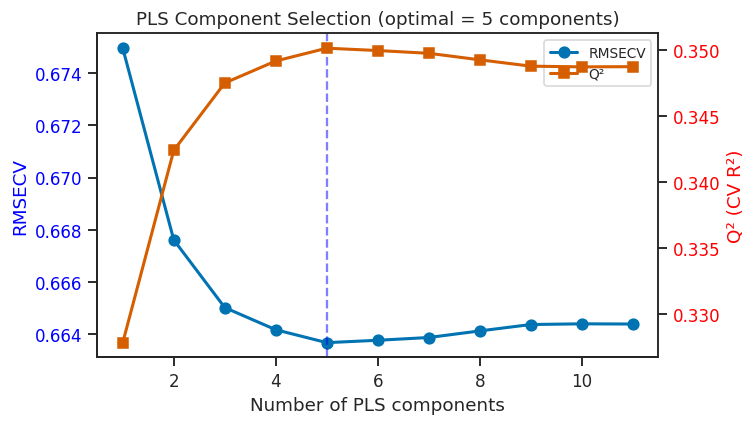

In [104]:
# TODO: train/test split (or set up cross-validation)
max_comp = 11
rmsecv = []
q2     = []
kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
quality = df['quality']

for nc in range(1, max_comp + 1):
    pls_tmp = PLSRegression(n_components=nc, scale=False)
    quality_pred = cross_val_predict(pls_tmp, X_scaled, quality, cv=kf).ravel()
    rmsecv.append(np.sqrt(mean_squared_error(quality, quality_pred)))
    q2.append(r2_score(quality, quality_pred))

opt_nc = np.argmin(rmsecv) + 1
print(f'Optimal number of components: {opt_nc}  (RMSECV = {rmsecv[opt_nc-1]:.2f})')

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(range(1, max_comp+1), rmsecv, 'bo-', lw=2, ms=7, label='RMSECV')
ax1.axvline(opt_nc, color='blue', ls='--', alpha=0.5)
ax2.plot(range(1, max_comp+1), q2, 'rs-', lw=2, ms=7, label='Q²')
ax1.set_xlabel('Number of PLS components')
ax1.set_ylabel('RMSECV', color='blue')
ax2.set_ylabel('Q² (CV R²)', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax1.set_title(f'PLS Component Selection (optimal = {opt_nc} components)')
sns.despine(ax=ax1)
plt.tight_layout()
plt.show()

R²      (train) = 0.3631
Q²      (CV)    = 0.3501
RMSECV         = 0.66


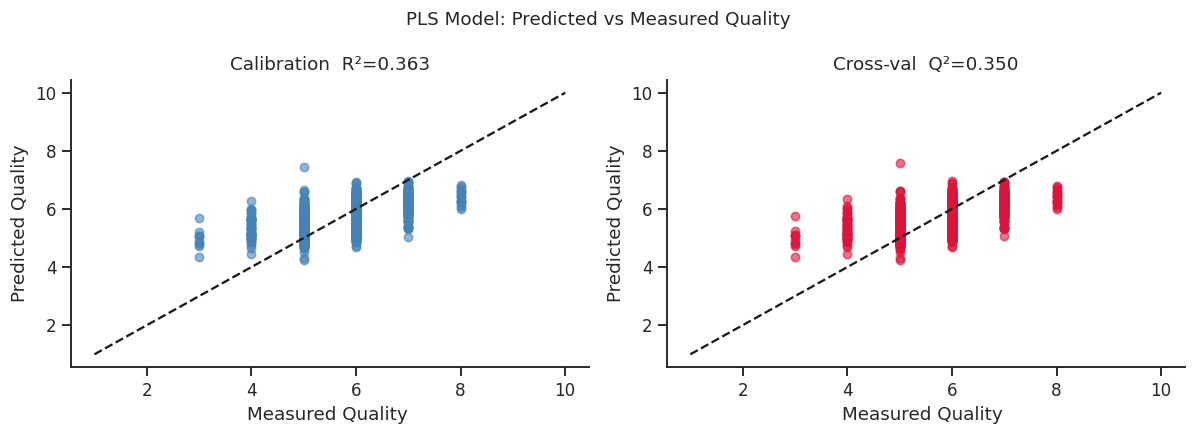

In [105]:
# TODO: fit PLSRegression; choose the number of latent variables using
# cross-validated RMSE or Q^2, not the training-set fit alone

pls = PLSRegression(n_components=opt_nc, scale=False)
pls.fit(X_scaled, quality)

quality_pred_train = pls.predict(X_scaled).ravel()
quality_pred_cv    = cross_val_predict(pls, X_scaled, quality, cv=kf).ravel()

r2_train = r2_score(quality, quality_pred_train)
r2_cv    = r2_score(quality, quality_pred_cv)
rmse_cv  = np.sqrt(mean_squared_error(quality, quality_pred_cv))

print(f'R²      (train) = {r2_train:.4f}')
print(f'Q²      (CV)    = {r2_cv:.4f}')
print(f'RMSECV         = {rmse_cv:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (quality_p, label, color) in zip(
    axes,
    [(quality_pred_train, f'Calibration  R²={r2_train:.3f}', 'steelblue'),
     (quality_pred_cv,   f'Cross-val  Q²={r2_cv:.3f}',      'crimson')]
):
    ax.scatter(quality, quality_p, s=30, alpha=0.6, color=color)
    lims = [min(quality.min(), quality_p.min())-2, max(quality.max(), quality_p.max())+2]
    ax.plot(lims, lims, 'k--', lw=1.5)
    ax.set_xlabel('Measured Quality ')
    ax.set_ylabel('Predicted Quality')
    ax.set_title(label)
    sns.despine(ax=ax)

plt.suptitle('PLS Model: Predicted vs Measured Quality', fontsize=12)
plt.tight_layout()
plt.show()

In [106]:
# TODO: report test-set RMSE and/or R^2, and a predicted-vs-observed plot
# (include the y=x identity line for reference)

### LDA (quality binned into categories)

In [107]:
# TODO: define your quality bins explicitly here (e.g. low / medium / high).
# State your bin edges and reasoning on the answer sheet (Checkpoint 3b) --
# this is a real modelling decision, not a formality.
# Check the resulting class sizes: are they balanced?

bins = [2, 5, 6, 8]
labels = ['low', 'medium', 'high']

y_cat = pd.cut(y, bins=bins, labels=labels)

print(y_cat)
print(y_cat.value_counts())


0          low
1          low
2          low
3       medium
5          low
         ...  
1593    medium
1594       low
1595    medium
1597       low
1598    medium
Name: quality, Length: 1359, dtype: category
Categories (3, object): ['low' < 'medium' < 'high']
quality
low       640
medium    535
high      184
Name: count, dtype: int64


In [108]:
# TODO: train/test split, then fit LinearDiscriminantAnalysis
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cat, test_size=0.25, random_state=RANDOM_STATE, stratify=y_cat)
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

# Explained variance ratio of each discriminant
print('Proportion of between-class variance explained:')
for i, ev in enumerate(lda.explained_variance_ratio_, 1):
    print(f'  LD{i}: {ev*100:.1f}%')

Proportion of between-class variance explained:
  LD1: 96.2%
  LD2: 3.8%


Classification report:
              precision    recall  f1-score   support

         low       0.64      0.74      0.68       160
      medium       0.50      0.48      0.49       134
        high       0.64      0.39      0.49        46

    accuracy                           0.59       340
   macro avg       0.59      0.54      0.55       340
weighted avg       0.59      0.59      0.58       340



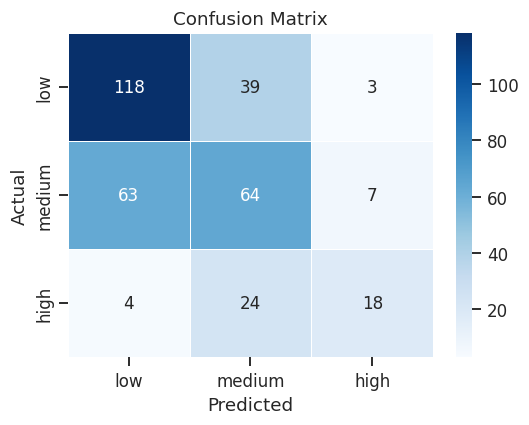

In [109]:
# TODO: report a confusion matrix (ConfusionMatrixDisplay) and per-class
# accuracy on the TEST set -- accuracy alone is not enough here

y_pred = lda.predict(X_test)

print('Classification report:')
print(classification_report(y_test, y_pred, labels=labels, target_names=labels))

cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()


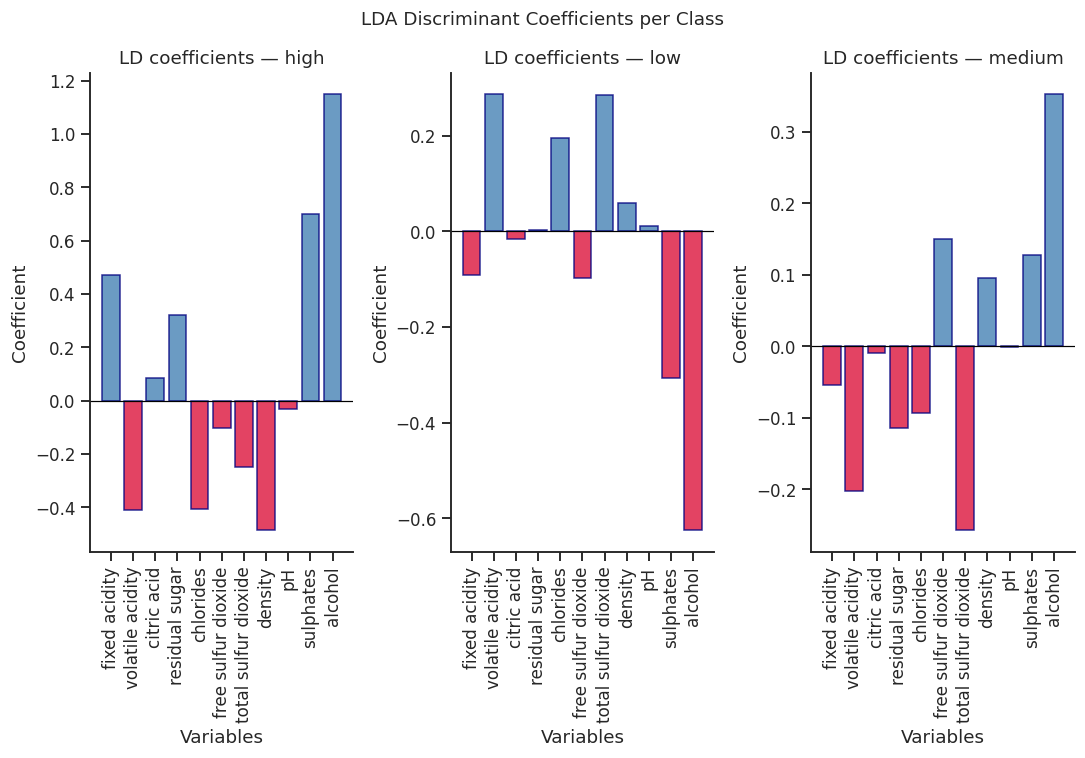

[[ 0.05974073 -0.19691674 -0.02653817  0.0180325  -0.10044305  0.04146353
  -0.09582888 -0.06189376 -0.05338665  0.16852507  0.28191846]]


In [110]:
# TODO: Checkpoint 3c/3d groundwork -- pull out and compare the top
# variables from both models (PLS coefficients vs. LDA discriminant
# loadings). Your written comparison goes on the answer sheet.
coef_df = pd.DataFrame(lda.coef_, index=lda.classes_, columns=parameters)

fig, axes = plt.subplots(1, 3, figsize=(10, 7))
for ax, grade in zip(axes.flat, lda.classes_):
    vals = coef_df.loc[grade]
    colors = ['steelblue' if v > 0 else 'crimson' for v in vals]
    ax.bar(parameters, vals, color=colors, edgecolor='navy', alpha=0.8)
    ax.tick_params(axis='x', rotation=90)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'LD coefficients — {grade}')
    ax.set_xlabel('Variables')
    ax.set_ylabel('Coefficient')
    sns.despine(ax=ax)

plt.suptitle('LDA Discriminant Coefficients per Class', fontsize=12)
plt.tight_layout()
plt.show()

print(pls.coef_)

---
## Step 4 — Does It Transfer? White Wine (3:00–3:45)

Repeat the analysis on `winequality-white.csv` and check whether your
Step 2/3 findings are genuine wine chemistry or specific to the red-wine
dataset. You only need to redo **one** of PLS/LDA here, not both.

- [ ] Curate the white wine data the same way as Step 1 (its own duplicate/quality-distribution answer will differ from red)
- [ ] Redo the PCA from Step 2 on white wine (→ **Checkpoint 4a**)
- [ ] Redo ONE of your two Step 3 models on white wine (→ **Checkpoint 4b**)

shape: (4898, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
Number of duplicate rows: 937


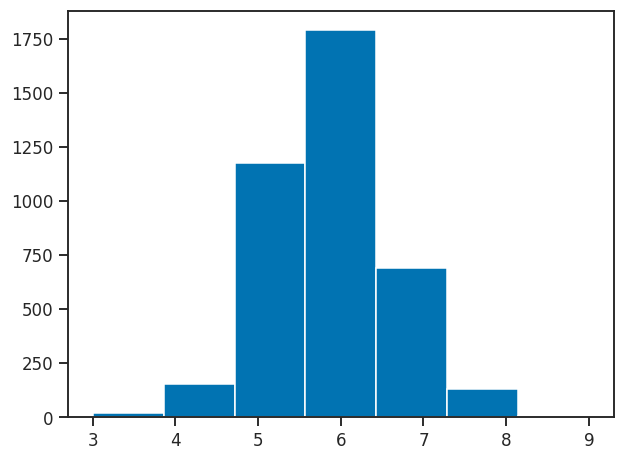

In [111]:
# TODO: load winequality-white.csv, curate it the same way as Step 1
# (missing values, duplicates, quality distribution)
df = pd.read_csv('winequality-white.csv', sep=';')
df.head()


print("shape:" , df.shape)
df.info()

df = df.dropna()

print("Number of duplicate rows:",df.duplicated().sum()) #check if there are duplicates

df_bad = df
df = df.drop_duplicates()

df['quality'].hist(bins = 7, grid=False)

X = df.drop('quality', axis=1)
y = df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
scores = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)


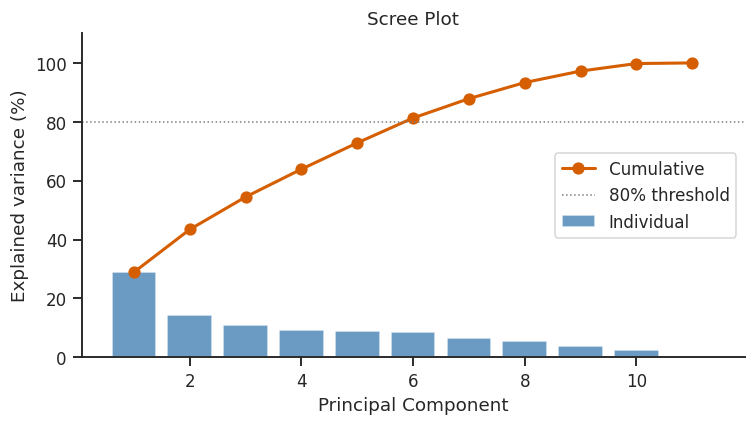

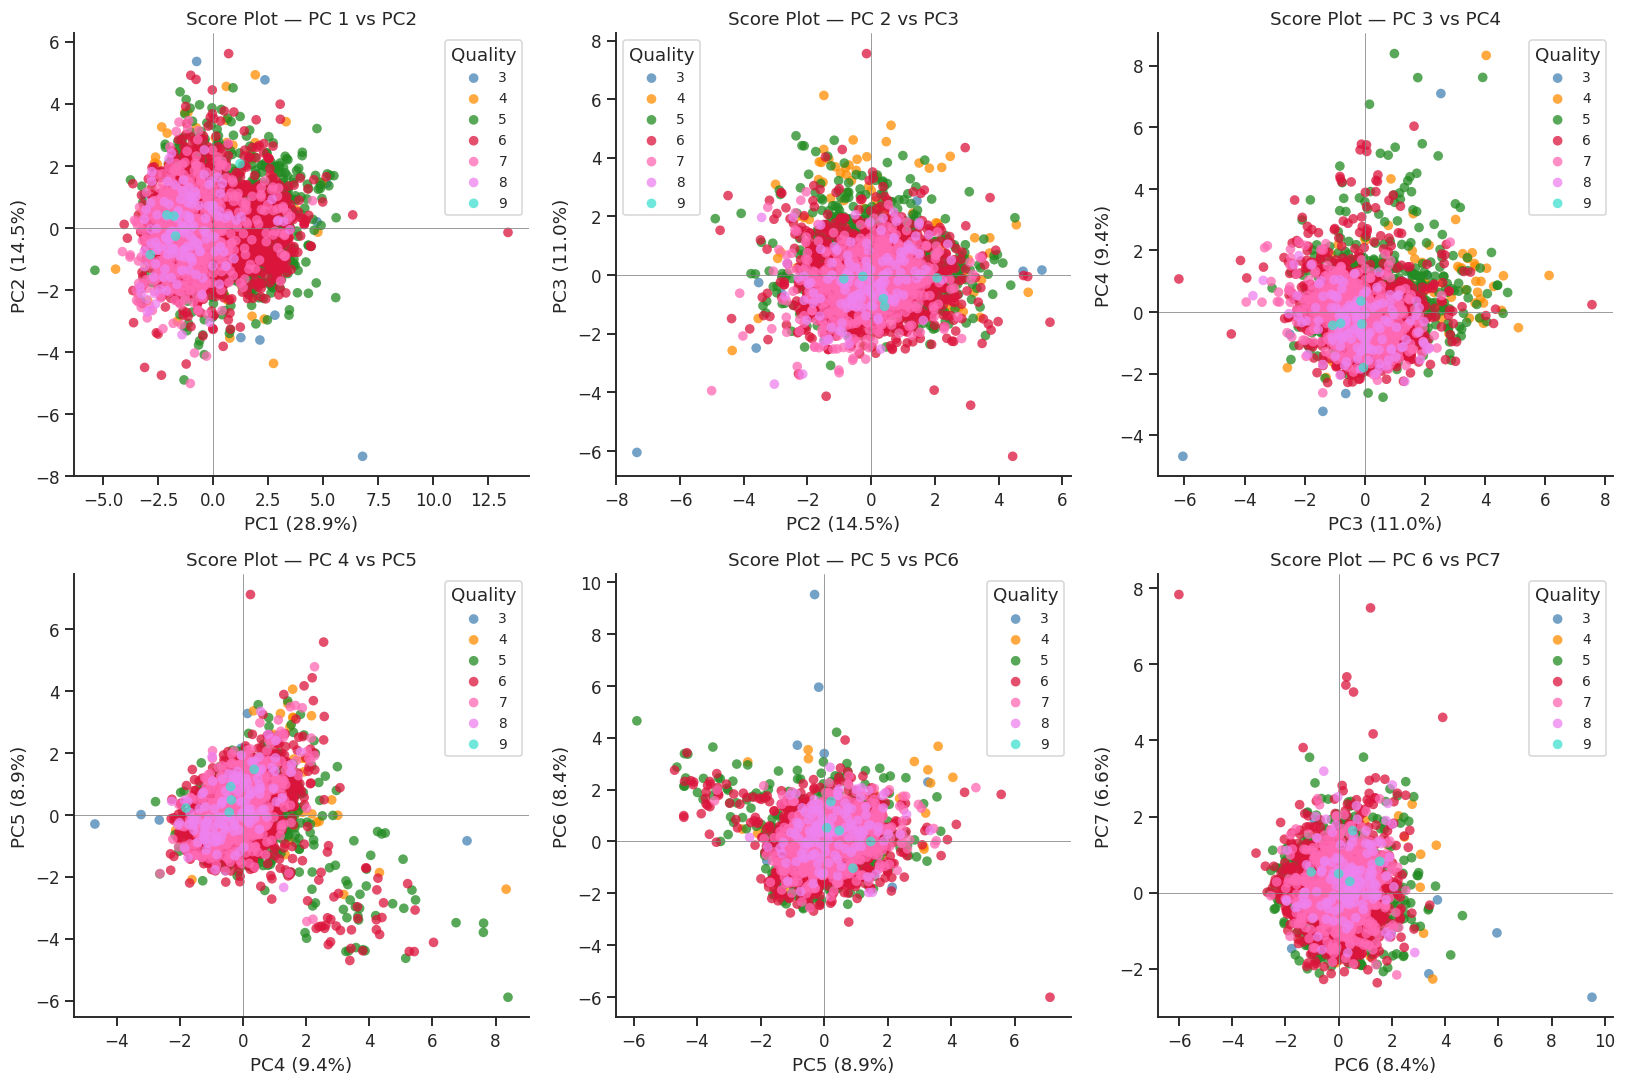

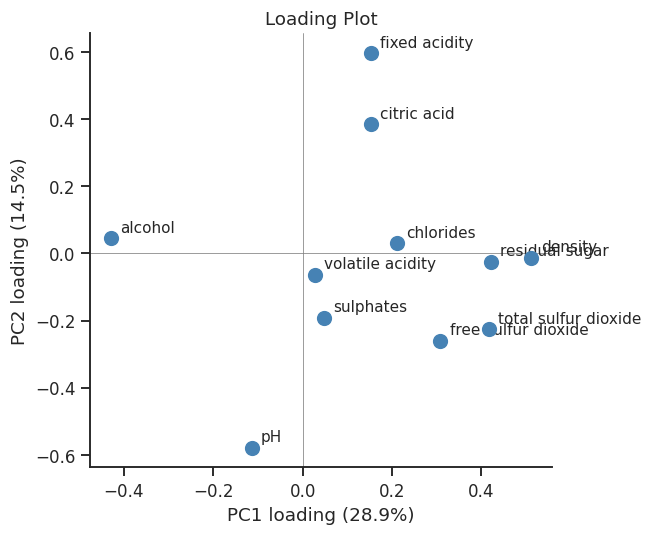

In [112]:
# TODO: standardise the white-wine predictors and redo the PCA + scree/
# score/loading plots from Step 2. Compare PC1's top-loading variables to
# what you found for red wine (Checkpoint 2c) -- write the comparison on
# the answer sheet (Checkpoint 4a).


#Plot scree plot to determine number of PC's
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.8, label='Individual')
ax.plot(range(1, len(explained)+1), cumulative*100, 'ro-', lw=2, ms=7, label='Cumulative')
ax.axhline(80, color='gray', ls=':', lw=1, label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('Scree Plot')
ax.legend()
ax.set_ylim(0, 110)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


#Plot score plot for all Pc's
qualities = df['quality'].values
quality_list = [3,4,5,6,7,8,9]
colors_map = dict(zip(quality_list, ['steelblue','darkorange','forestgreen','crimson','hotpink', 'violet', 'turquoise']))
point_colors = [colors_map[q] for q in qualities]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i in range(3):
  ax = axes[0,i]
  for quality, color in colors_map.items():
      mask = qualities == quality
      ax.scatter(scores[mask, i], scores[mask, i+1], c=color,
                 label=quality, s=40, alpha=0.75, edgecolors='none')
  ax.set_xlabel(f'PC{i+1} ({explained[i]*100:.1f}%)')
  ax.set_ylabel(f'PC{i+2} ({explained[i+1]*100:.1f}%)')
  ax.set_title(f'Score Plot — PC {i+1} vs PC{i+2}')
  ax.legend(title='Quality', fontsize=9)
  ax.axhline(0, color='gray', lw=0.5)
  ax.axvline(0, color='gray', lw=0.5)
  sns.despine(ax=ax)
  i=+1
for i in range(3,6):
  ax = axes[1,i-3]
  for quality, color in colors_map.items():
      mask = qualities == quality
      ax.scatter(scores[mask, i], scores[mask, i+1], c=color,
                 label=quality, s=40, alpha=0.75, edgecolors='none')
  ax.set_xlabel(f'PC{i+1} ({explained[i]*100:.1f}%)')
  ax.set_ylabel(f'PC{i+2} ({explained[i+1]*100:.1f}%)')
  ax.set_title(f'Score Plot — PC {i+1} vs PC{i+2}')
  ax.legend(title='Quality', fontsize=9)
  ax.axhline(0, color='gray', lw=0.5)
  ax.axvline(0, color='gray', lw=0.5)
  sns.despine(ax=ax)
  i=+1
fig.tight_layout()
plt.show()

parameters= df.columns[:-1]
loadings = pca.components_.T   # shape (n_variables, n_components)

# Loading plot for PC1 and PC2
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(loadings[:, 0], loadings[:, 1], color='steelblue', s=80, zorder=5)
for i, elem in enumerate(parameters):
    ax.annotate(elem, (loadings[i, 0], loadings[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(f'PC1 loading ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 loading ({explained[1]*100:.1f}%)')
ax.set_title('Loading Plot')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()






quality
medium    1788
low       1348
high       825
Name: count, dtype: int64
Proportion of between-class variance explained:
  LD1: 94.5%
  LD2: 5.5%
Classification report:
              precision    recall  f1-score   support

         low       0.64      0.56      0.60       337
      medium       0.53      0.64      0.58       447
        high       0.53      0.40      0.45       207

    accuracy                           0.56       991
   macro avg       0.57      0.53      0.54       991
weighted avg       0.57      0.56      0.56       991



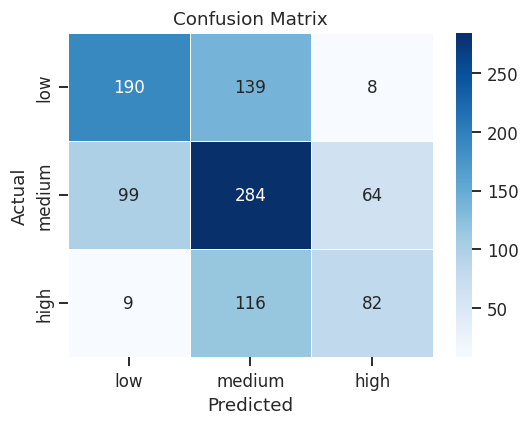

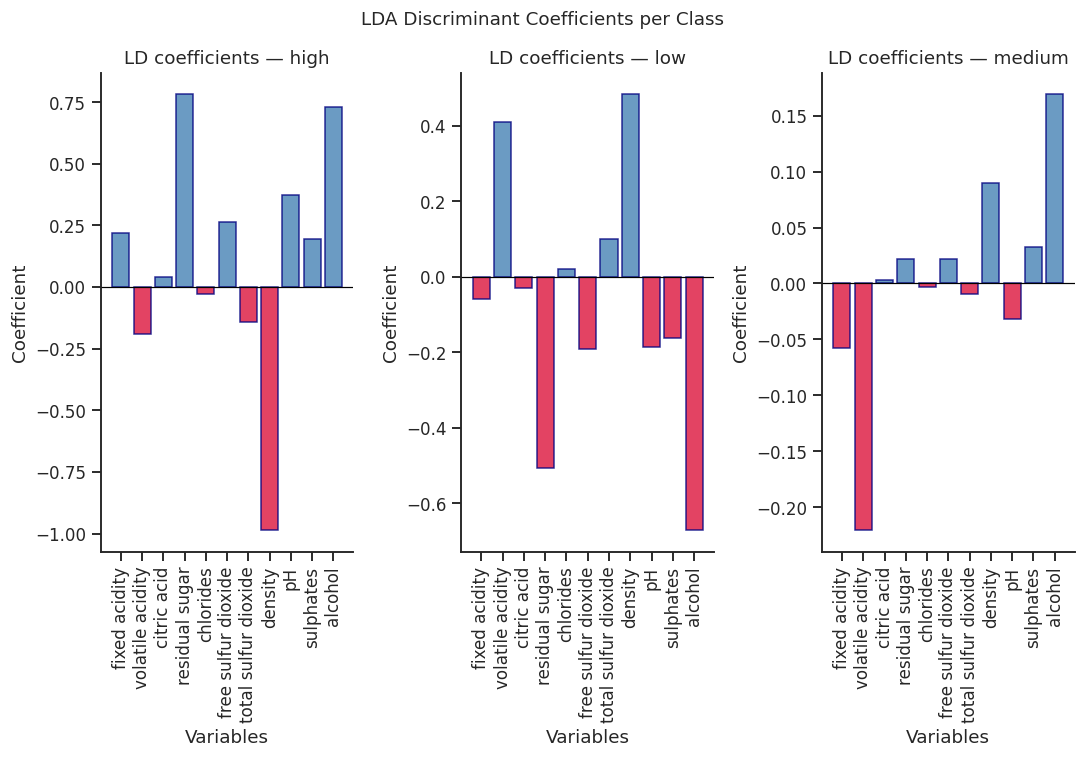

In [113]:
# TODO: redo ONE of your two Step 3 models (PLS or LDA -- your choice) on
# white wine, same methodology as before. Compare validated performance and
# top variables to your red-wine result (Checkpoint 3a/3b/3d) -- write the
# comparison on the answer sheet (Checkpoint 4b).


bins = [2, 5, 6, 9]
labels = ['low', 'medium', 'high']

y_cat = pd.cut(y, bins=bins, labels=labels)

print(y_cat.value_counts())


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cat, test_size=0.25, random_state=RANDOM_STATE, stratify=y_cat)
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

# Explained variance ratio of each discriminant
print('Proportion of between-class variance explained:')
for i, ev in enumerate(lda.explained_variance_ratio_, 1):
    print(f'  LD{i}: {ev*100:.1f}%')




y_pred = lda.predict(X_test)

print('Classification report:')
print(classification_report(y_test, y_pred, labels=labels, target_names=labels))

cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()


coef_df = pd.DataFrame(lda.coef_, index=lda.classes_, columns=parameters)

fig, axes = plt.subplots(1, 3, figsize=(10, 7))
for ax, grade in zip(axes.flat, lda.classes_):
    vals = coef_df.loc[grade]
    colors = ['steelblue' if v > 0 else 'crimson' for v in vals]
    ax.bar(parameters, vals, color=colors, edgecolor='navy', alpha=0.8)
    ax.tick_params(axis='x', rotation=90)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'LD coefficients — {grade}')
    ax.set_xlabel('Variables')
    ax.set_ylabel('Coefficient')
    sns.despine(ax=ax)

plt.suptitle('LDA Discriminant Coefficients per Class', fontsize=12)
plt.tight_layout()
plt.show()


---
## Wrap-up (3:45–4:00)

- [ ] Finalise your answer sheet (Checkpoints 1a–4b)

Hand in **this notebook** + your **answer sheet** — no separate report.